Original dataset
Shape: (114000, 21)

After keeping four genres
Number of rows: 4000
track_genre
classical    1000
hip-hop      1000
mandopop     1000
metal        1000
Name: count, dtype: int64

After duplicate track_id removal: 3916
After duplicate audio-feature removal: 3408

Tracks per genre:
track_genre
classical    814
hip-hop      747
mandopop     985
metal        862
Name: count, dtype: int64

Sanity check passed: n = 3408

Standardisation check
Means:
[ 0. -0.  0. -0. -0. -0.  0.  0. -0.]

Standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]

Z shape: (3408, 9)

Tracks per genre
    Genre  Number of tracks
classical               814
  hip-hop               747
 mandopop               985
    metal               862

Total n = 3408

Feature skewness
         Feature  Skewness
    danceability -0.003852
          energy -0.310208
        loudness -1.651509
     speechiness  3.042636
    acousticness  0.337738
instrumentalness  1.710241
        liveness  2.300314
         valence  

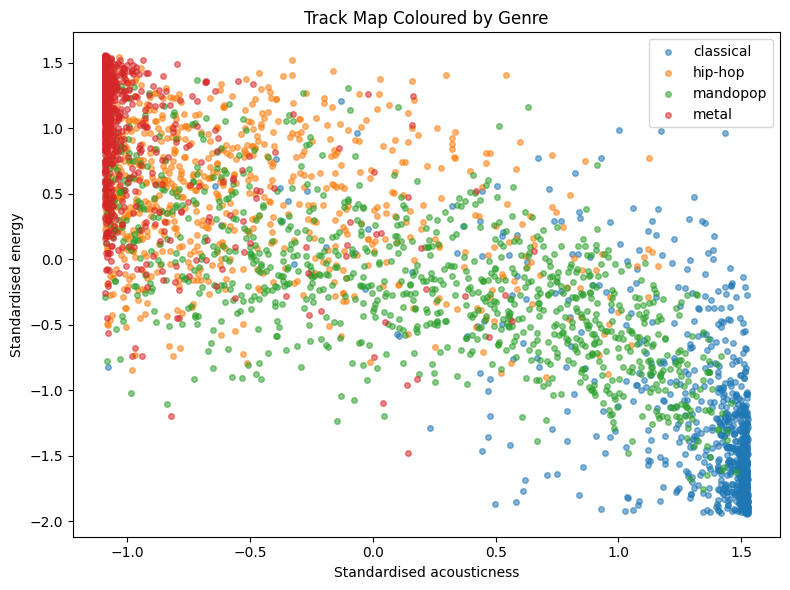

Custom k-means verification
Initial point indices:
[2898  428   85   43]

Custom final SSE:
15821.134129240338

Sklearn final SSE:
15821.134129240334

Absolute difference:
3.637978807091713e-12

Random
Farthest-first
k-means++
  strategy  seed          phi0         phi20
0   Random     0  30271.539010  15811.660953
1   Random     1  34570.447842  15831.971062
2   Random     2  25101.903693  16359.761540
3   Random     3  41054.106002  17143.258973
4   Random     4  27263.019661  15811.241752



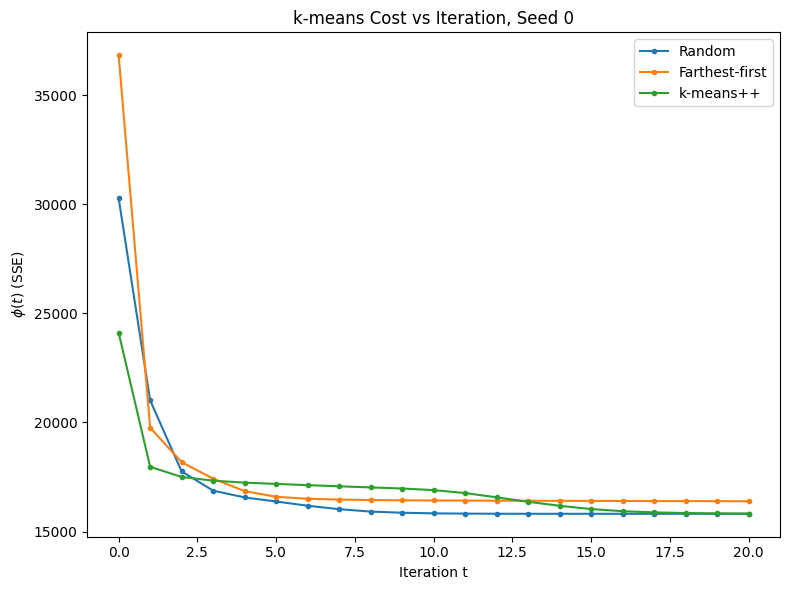

Initialisation strategy summary
      Strategy  Median phi(0)  Min phi(20)  Median phi(20)  Max phi(20)
        Random   29350.866990 15811.066258    15818.526187 17186.418168
Farthest-first   44622.971103 15824.768283    16373.390135 16458.666061
     k-means++   28192.526840 15811.389038    16157.343406 17143.258973

Best starting strategy by median phi(0): k-means++
Best ending strategy by median phi(20): Random

Farthest-first selected tracks, seed 0
 Selection order  Index                                Track                                          Artist     Genre Most extreme feature  Standardised value
               1   2898 Wild World - 2009 Remastered Version                                         Mr. Big     metal                tempo            0.787746
               2    344            Sri Venkatesa Suprabhatam M. S. Subbulakshmi;T. K. Murthy;V.V.Subramaniam classical          speechiness            9.662232
               3    274                  Glassworks: Opening 

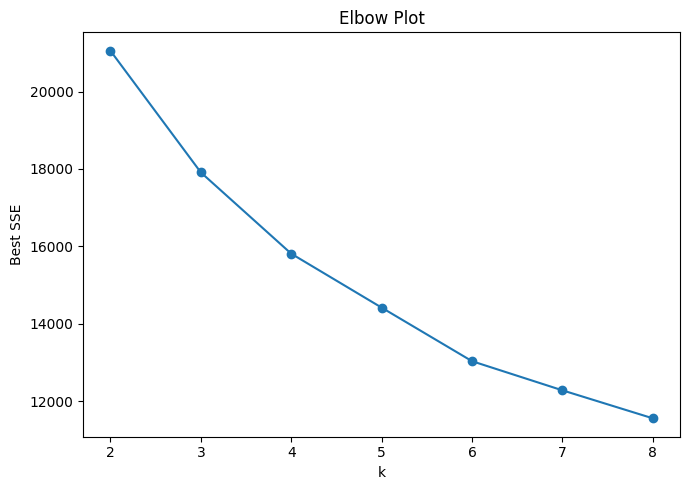

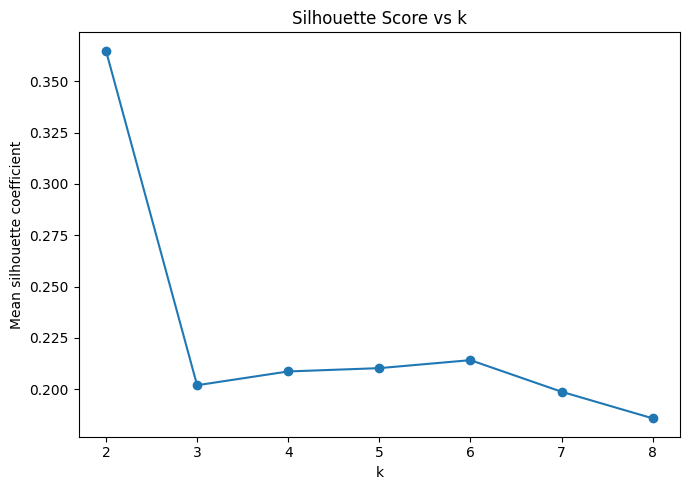

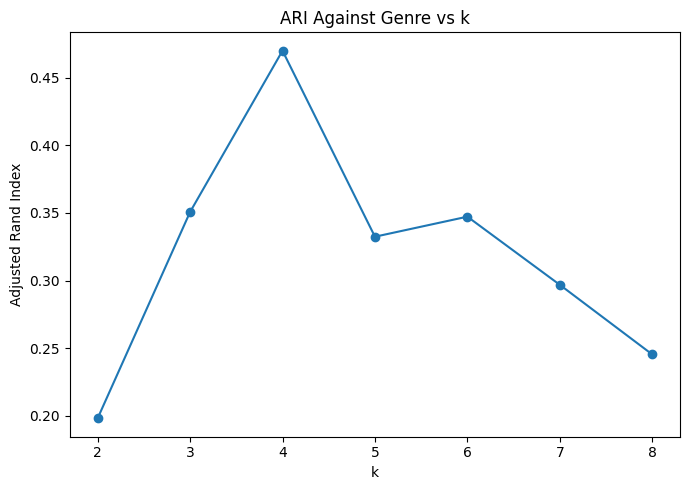

Criterion results
Highest silhouette: k = 2 , score = 0.3648425500816621
Highest ARI: k = 4 , score = 0.46994058271636135

For the elbow criterion, inspect the SSE curve rather than automatically taking the smallest SSE.

Best k=4 seed: 3
Best k=4 SSE: 15811.389037790766


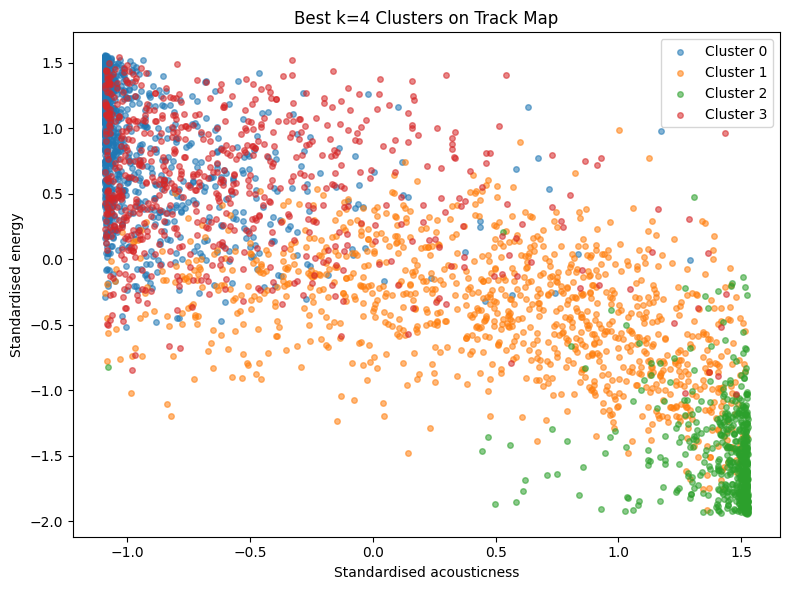

Null dataset 1/10
Null dataset 2/10
Null dataset 3/10
Null dataset 4/10
Null dataset 5/10
Null dataset 6/10
Null dataset 7/10
Null dataset 8/10
Null dataset 9/10
Null dataset 10/10

Null dataset SSE summary
 k         mean        std
 2 27558.902549 213.529683
 3 25118.785061 165.673673
 4 23021.077872  84.049306
 5 21395.392383 172.163207
 6 19825.271404 132.844798
 7 18821.665632 212.812810
 8 17982.144837  52.274182

Real vs null SSE
 k     Real SSE  Mean null SSE  Null SSE std
 2 21055.395606   27558.902549    213.529683
 3 17911.714154   25118.785061    165.673673
 4 15811.389038   23021.077872     84.049306
 5 14417.396888   21395.392383    172.163207
 6 13033.219406   19825.271404    132.844798
 7 12280.039933   18821.665632    212.812810
 8 11556.829987   17982.144837     52.274182


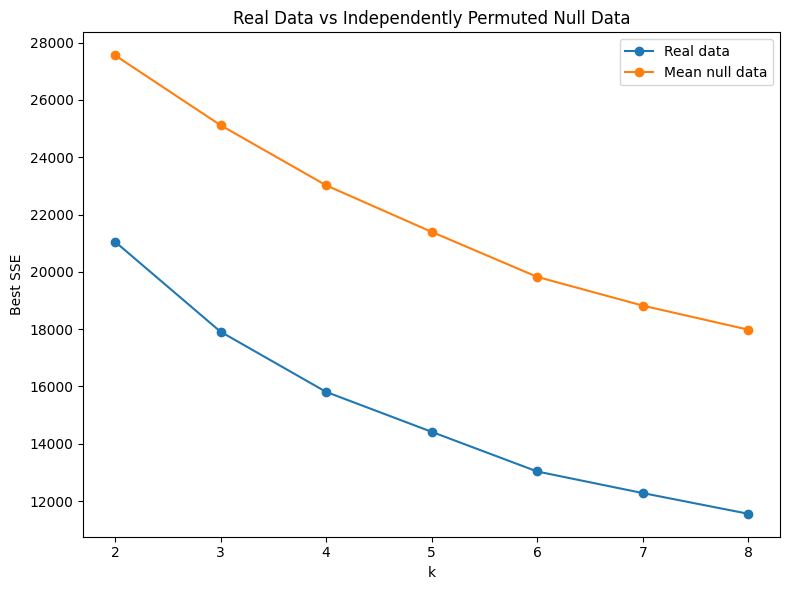


PART II COMPLETE
n = 3408

Best overall final SSE from initialisation experiment: 15811.066258387256

Best k=4 SSE: 15811.389037790766

Best silhouette k: 2
Best ARI k: 4

Generated files:
 - part2_genre_counts.csv
 - part2_skewness.csv
 - part2a_track_map_genre.png
 - part2c_seed0_cost_curves.png
 - part2c_initialisation_summary.csv
 - part2c_farthest_first_seed0_tracks.csv
 - part2d_k_results.csv
 - part2d_elbow_plot.png
 - part2d_silhouette.png
 - part2d_ari.png
 - part2d_best_k4_track_map.png
 - part2d_null_sse_summary.csv
 - part2d_real_vs_null_sse.csv
 - part2d_real_vs_null_sse.png


In [1]:
# ============================================================
# Machine Learning - Assignment 1
# Part II: k-means from Scratch
# ============================================================

# If Colab cannot read hf:// URLs, uncomment:
# !pip -q install huggingface_hub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score


# ============================================================
# 0. SETTINGS
# ============================================================

FEATURES = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

GENRES = [
    "classical",
    "hip-hop",
    "mandopop",
    "metal",
]

MAX_ITER = 20


# ============================================================
# 1. LOAD DATA
# ============================================================

url = "hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv"

df = pd.read_csv(url)

print("=" * 70)
print("Original dataset")
print("=" * 70)
print("Shape:", df.shape)
print()


# ============================================================
# 2. FILTER FOUR GENRES
# ============================================================

data = df[df["track_genre"].isin(GENRES)].copy()

print("=" * 70)
print("After keeping four genres")
print("=" * 70)
print("Number of rows:", len(data))
print(data["track_genre"].value_counts().sort_index())
print()


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

# First remove duplicate track IDs
data = data.drop_duplicates(
    subset="track_id",
    keep="first"
).copy()

print("After duplicate track_id removal:", len(data))

# Then remove duplicate nine-feature vectors
data = data.drop_duplicates(
    subset=FEATURES,
    keep="first"
).copy()

data = data.reset_index(drop=True)

print("After duplicate audio-feature removal:", len(data))
print()

print("Tracks per genre:")
print(data["track_genre"].value_counts().sort_index())
print()

# Assignment sanity check
assert len(data) == 3408, \
    f"Sanity check failed: expected 3408 tracks, got {len(data)}"

print("Sanity check passed: n = 3408")
print()


# ============================================================
# 4. STANDARDISE FEATURES
# ============================================================

X = data[FEATURES].to_numpy(dtype=float)

feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0, ddof=0)

Z = (X - feature_mean) / feature_std

print("=" * 70)
print("Standardisation check")
print("=" * 70)

print("Means:")
print(np.round(Z.mean(axis=0), 10))

print("\nStandard deviations:")
print(np.round(Z.std(axis=0, ddof=0), 10))

print("\nZ shape:", Z.shape)
print()


# ============================================================
# 5. DATASET STATISTICS
# ============================================================

genre_counts = (
    data["track_genre"]
    .value_counts()
    .reindex(GENRES)
)

genre_table = pd.DataFrame({
    "Genre": genre_counts.index,
    "Number of tracks": genre_counts.values
})

print("=" * 70)
print("Tracks per genre")
print("=" * 70)
print(genre_table.to_string(index=False))
print()
print("Total n =", len(data))
print()


# ============================================================
# 6. SKEWNESS
# ============================================================

# pandas skew() reports sample skewness.
# The assignment asks only to report skewness, so this is acceptable.
skew_values = data[FEATURES].skew()

skew_table = pd.DataFrame({
    "Feature": FEATURES,
    "Skewness": [skew_values[f] for f in FEATURES]
})

print("=" * 70)
print("Feature skewness")
print("=" * 70)
print(skew_table.to_string(index=False))
print()

genre_table.to_csv("part2_genre_counts.csv", index=False)
skew_table.to_csv("part2_skewness.csv", index=False)


# ============================================================
# 7. TRACK MAP COLOURED BY GENRE
# ============================================================

acoustic_idx = FEATURES.index("acousticness")
energy_idx = FEATURES.index("energy")

plt.figure(figsize=(8, 6))

for genre in GENRES:
    mask = data["track_genre"].to_numpy() == genre

    plt.scatter(
        Z[mask, acoustic_idx],
        Z[mask, energy_idx],
        s=16,
        alpha=0.55,
        label=genre
    )

plt.xlabel("Standardised acousticness")
plt.ylabel("Standardised energy")
plt.title("Track Map Coloured by Genre")
plt.legend()
plt.tight_layout()
plt.savefig(
    "part2a_track_map_genre.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# 8. DISTANCE FUNCTION
# ============================================================

def squared_distances(X, C):
    """
    Pairwise squared Euclidean distances.

    Parameters
    ----------
    X : shape (n, d)
    C : shape (k, d)

    Returns
    -------
    D2 : shape (n, k)
        D2[i, j] = ||X[i] - C[j]||^2
    """

    X2 = np.sum(X * X, axis=1, keepdims=True)
    C2 = np.sum(C * C, axis=1)[None, :]

    D2 = X2 + C2 - 2.0 * X @ C.T

    # Numerical roundoff protection
    return np.maximum(D2, 0.0)


# ============================================================
# 9. K-MEANS FROM SCRATCH
# ============================================================

def kmeans(X, C0, max_iter=20):
    """
    Lloyd's k-means algorithm implemented from scratch.

    Returns
    -------
    assignments : final cluster labels
    centroids   : final centroids
    cost_history: phi(0), ..., phi(max_iter)
    """

    X = np.asarray(X, dtype=float)
    C = np.asarray(C0, dtype=float).copy()

    n = X.shape[0]
    k = C.shape[0]

    cost_history = []

    # --------------------------------------------------------
    # phi(0): cost under initial centroids
    # --------------------------------------------------------

    D2 = squared_distances(X, C)

    # np.argmin breaks ties by smallest index
    assignments = np.argmin(D2, axis=1)

    phi0 = D2[np.arange(n), assignments].sum()
    cost_history.append(phi0)

    # --------------------------------------------------------
    # Lloyd updates
    # --------------------------------------------------------

    for _ in range(max_iter):

        # Assignment step
        D2 = squared_distances(X, C)
        assignments = np.argmin(D2, axis=1)

        # Update step
        new_C = C.copy()

        # Loop is over clusters, NOT over data points
        for j in range(k):
            mask = assignments == j

            if np.any(mask):
                new_C[j] = X[mask].mean(axis=0)
            else:
                # Empty cluster:
                # keep previous centroid
                new_C[j] = C[j]

        C = new_C

        # Compute cost after update
        D2 = squared_distances(X, C)
        assignments = np.argmin(D2, axis=1)

        phi = D2[
            np.arange(n),
            assignments
        ].sum()

        cost_history.append(phi)

    return (
        assignments,
        C,
        np.asarray(cost_history)
    )


# ============================================================
# 10. RANDOM INITIALISATION
# ============================================================

def init_random(X, k, seed):
    """
    Select k distinct observations uniformly at random.

    First point is drawn exactly as required:
    rng.integers(n)
    """

    n = X.shape[0]

    rng = np.random.default_rng(seed)

    first = int(rng.integers(n))

    remaining = np.delete(
        np.arange(n),
        first
    )

    rest = rng.choice(
        remaining,
        size=k - 1,
        replace=False
    )

    indices = np.concatenate(
        ([first], rest)
    ).astype(int)

    return X[indices].copy(), indices


# ============================================================
# 11. FARTHEST-FIRST INITIALISATION
# ============================================================

def init_farthest_first(X, k, seed):

    n = X.shape[0]

    rng = np.random.default_rng(seed)

    first = int(rng.integers(n))

    chosen = [first]

    min_d2 = squared_distances(
        X,
        X[[first]]
    )[:, 0]

    # Prevent selecting the point again
    min_d2[first] = -np.inf

    while len(chosen) < k:

        # np.argmax chooses smallest index in a tie
        next_idx = int(
            np.argmax(min_d2)
        )

        chosen.append(next_idx)

        d2_new = squared_distances(
            X,
            X[[next_idx]]
        )[:, 0]

        min_d2 = np.minimum(
            min_d2,
            d2_new
        )

        min_d2[chosen] = -np.inf

    chosen = np.array(
        chosen,
        dtype=int
    )

    return X[chosen].copy(), chosen


# ============================================================
# 12. K-MEANS++ INITIALISATION
# ============================================================

def init_kmeans_pp(X, k, seed):

    n = X.shape[0]

    rng = np.random.default_rng(seed)

    first = int(rng.integers(n))

    chosen = [first]

    min_d2 = squared_distances(
        X,
        X[[first]]
    )[:, 0]

    min_d2[first] = 0.0

    while len(chosen) < k:

        weights = min_d2.copy()

        weights[chosen] = 0.0

        total = weights.sum()

        if total <= 0:

            remaining = np.setdiff1d(
                np.arange(n),
                np.asarray(chosen)
            )

            next_idx = int(
                rng.choice(remaining)
            )

        else:

            probabilities = weights / total

            next_idx = int(
                rng.choice(
                    n,
                    p=probabilities
                )
            )

        chosen.append(next_idx)

        d2_new = squared_distances(
            X,
            X[[next_idx]]
        )[:, 0]

        min_d2 = np.minimum(
            min_d2,
            d2_new
        )

        min_d2[chosen] = 0.0

    chosen = np.array(
        chosen,
        dtype=int
    )

    return X[chosen].copy(), chosen


# ============================================================
# 13. VERIFY CUSTOM K-MEANS AGAINST SKLEARN
# ============================================================

print("=" * 70)
print("Custom k-means verification")
print("=" * 70)

C0, initial_indices = init_kmeans_pp(
    Z,
    k=4,
    seed=0
)

custom_labels, custom_centroids, custom_history = kmeans(
    Z,
    C0,
    max_iter=20
)

custom_sse = custom_history[-1]

sk_model = KMeans(
    n_clusters=4,
    init=C0.copy(),
    n_init=1,
    max_iter=20,
    algorithm="lloyd",
    random_state=0
)

sk_model.fit(Z)

sklearn_sse = sk_model.inertia_

print("Initial point indices:")
print(initial_indices)

print("\nCustom final SSE:")
print(custom_sse)

print("\nSklearn final SSE:")
print(sklearn_sse)

print("\nAbsolute difference:")
print(abs(custom_sse - sklearn_sse))
print()


# ============================================================
# 14. RUN INITIALISATION EXPERIMENT
# ============================================================

strategies = {
    "Random": init_random,
    "Farthest-first": init_farthest_first,
    "k-means++": init_kmeans_pp
}

results = []

seed0_histories = {}

for strategy_name, init_func in strategies.items():

    print("=" * 70)
    print(strategy_name)
    print("=" * 70)

    for seed in range(20):

        C0, indices = init_func(
            Z,
            k=4,
            seed=seed
        )

        labels, centroids, history = kmeans(
            Z,
            C0,
            max_iter=20
        )

        results.append({
            "strategy": strategy_name,
            "seed": seed,
            "phi0": history[0],
            "phi20": history[-1]
        })

        if seed == 0:
            seed0_histories[
                strategy_name
            ] = history

results_df = pd.DataFrame(results)

print(results_df.head())
print()


# ============================================================
# 15. SEED 0 COST CURVES
# ============================================================

plt.figure(figsize=(8, 6))

for strategy_name, history in seed0_histories.items():

    plt.plot(
        np.arange(len(history)),
        history,
        marker="o",
        markersize=3,
        label=strategy_name
    )

plt.xlabel("Iteration t")
plt.ylabel(r"$\phi(t)$ (SSE)")
plt.title("k-means Cost vs Iteration, Seed 0")
plt.legend()
plt.tight_layout()

plt.savefig(
    "part2c_seed0_cost_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. INITIALISATION SUMMARY TABLE
# ============================================================

summary_rows = []

for strategy_name in strategies.keys():

    tmp = results_df[
        results_df["strategy"] == strategy_name
    ]

    summary_rows.append({
        "Strategy": strategy_name,
        "Median phi(0)": tmp["phi0"].median(),
        "Min phi(20)": tmp["phi20"].min(),
        "Median phi(20)": tmp["phi20"].median(),
        "Max phi(20)": tmp["phi20"].max(),
    })

summary_table = pd.DataFrame(
    summary_rows
)

print("=" * 70)
print("Initialisation strategy summary")
print("=" * 70)

print(
    summary_table.to_string(
        index=False
    )
)

print()

summary_table.to_csv(
    "part2c_initialisation_summary.csv",
    index=False
)


# ============================================================
# 17. IDENTIFY BEST START / BEST END
# ============================================================

best_start = (
    summary_table
    .sort_values("Median phi(0)")
    .iloc[0]
)

best_end = (
    summary_table
    .sort_values("Median phi(20)")
    .iloc[0]
)

print(
    "Best starting strategy by median phi(0):",
    best_start["Strategy"]
)

print(
    "Best ending strategy by median phi(20):",
    best_end["Strategy"]
)

print()


# ============================================================
# 18. FARTHEST-FIRST SEED 0 SELECTED TRACKS
# ============================================================

C_ff, ff_indices = init_farthest_first(
    Z,
    k=4,
    seed=0
)

print("=" * 70)
print("Farthest-first selected tracks, seed 0")
print("=" * 70)

selected_rows = []

for order, idx in enumerate(ff_indices, start=1):

    zrow = Z[idx]

    # Most extreme standardised feature
    extreme_idx = int(
        np.argmax(
            np.abs(zrow)
        )
    )

    selected_rows.append({
        "Selection order": order,
        "Index": idx,
        "Track": data.loc[idx, "track_name"],
        "Artist": data.loc[idx, "artists"],
        "Genre": data.loc[idx, "track_genre"],
        "Most extreme feature": FEATURES[extreme_idx],
        "Standardised value": zrow[extreme_idx]
    })

ff_tracks = pd.DataFrame(
    selected_rows
)

print(
    ff_tracks.to_string(
        index=False
    )
)

ff_tracks.to_csv(
    "part2c_farthest_first_seed0_tracks.csv",
    index=False
)

print()


# ============================================================
# 19. CHOOSING k = 2,...,8
# ============================================================

genre_labels, genre_names = pd.factorize(
    data["track_genre"]
)

k_results = []

best_runs = {}

for k in range(2, 9):

    print(f"Running k = {k}")

    best_sse = np.inf
    best_labels = None
    best_centroids = None
    best_seed = None

    for seed in range(10):

        C0, indices = init_kmeans_pp(
            Z,
            k=k,
            seed=seed
        )

        labels, centroids, history = kmeans(
            Z,
            C0,
            max_iter=20
        )

        final_sse = history[-1]

        if final_sse < best_sse:

            best_sse = final_sse
            best_labels = labels.copy()
            best_centroids = centroids.copy()
            best_seed = seed

    # Compute validity metrics for best run
    sil = silhouette_score(
        Z,
        best_labels
    )

    ari = adjusted_rand_score(
        genre_labels,
        best_labels
    )

    k_results.append({
        "k": k,
        "best_seed": best_seed,
        "best_SSE": best_sse,
        "silhouette": sil,
        "ARI": ari
    })

    best_runs[k] = {
        "seed": best_seed,
        "SSE": best_sse,
        "labels": best_labels,
        "centroids": best_centroids
    }

k_table = pd.DataFrame(
    k_results
)

print()
print("=" * 70)
print("Choosing k results")
print("=" * 70)

print(
    k_table.to_string(
        index=False
    )
)

k_table.to_csv(
    "part2d_k_results.csv",
    index=False
)

print()


# ============================================================
# 20. ELBOW PLOT
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    k_table["k"],
    k_table["best_SSE"],
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Best SSE")
plt.title("Elbow Plot")

plt.xticks(
    range(2, 9)
)

plt.tight_layout()

plt.savefig(
    "part2d_elbow_plot.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. SILHOUETTE PLOT
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    k_table["k"],
    k_table["silhouette"],
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Mean silhouette coefficient")
plt.title("Silhouette Score vs k")

plt.xticks(
    range(2, 9)
)

plt.tight_layout()

plt.savefig(
    "part2d_silhouette.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. ARI PLOT
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    k_table["k"],
    k_table["ARI"],
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Adjusted Rand Index")
plt.title("ARI Against Genre vs k")

plt.xticks(
    range(2, 9)
)

plt.tight_layout()

plt.savefig(
    "part2d_ari.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 23. WHICH k EACH CRITERION FAVOURS
# ============================================================

best_silhouette_row = (
    k_table
    .loc[
        k_table["silhouette"].idxmax()
    ]
)

best_ari_row = (
    k_table
    .loc[
        k_table["ARI"].idxmax()
    ]
)

print("=" * 70)
print("Criterion results")
print("=" * 70)

print(
    "Highest silhouette: k =",
    int(best_silhouette_row["k"]),
    ", score =",
    best_silhouette_row["silhouette"]
)

print(
    "Highest ARI: k =",
    int(best_ari_row["k"]),
    ", score =",
    best_ari_row["ARI"]
)

print()
print(
    "For the elbow criterion, inspect the SSE curve "
    "rather than automatically taking the smallest SSE."
)

print()


# ============================================================
# 24. BEST k=4 CLUSTER MAP
# ============================================================

labels_k4 = best_runs[4]["labels"]

print(
    "Best k=4 seed:",
    best_runs[4]["seed"]
)

print(
    "Best k=4 SSE:",
    best_runs[4]["SSE"]
)

plt.figure(figsize=(8, 6))

for cluster in np.unique(labels_k4):

    mask = labels_k4 == cluster

    plt.scatter(
        Z[mask, acoustic_idx],
        Z[mask, energy_idx],
        s=16,
        alpha=0.55,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Standardised acousticness")
plt.ylabel("Standardised energy")
plt.title("Best k=4 Clusters on Track Map")
plt.legend()

plt.tight_layout()

plt.savefig(
    "part2d_best_k4_track_map.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 25. NULL DATASETS
# ============================================================

def make_null_dataset(Z, seed):
    """
    Independently permute every column.
    """

    rng = np.random.default_rng(seed)

    Z_null = np.empty_like(Z)

    for j in range(Z.shape[1]):

        Z_null[:, j] = rng.permutation(
            Z[:, j]
        )

    return Z_null


# ============================================================
# 26. HELPER: BEST SSE FOR GIVEN k
# ============================================================

def best_sse_over_10_seeds(X, k):

    best_sse = np.inf

    for seed in range(10):

        C0, indices = init_kmeans_pp(
            X,
            k=k,
            seed=seed
        )

        labels, centroids, history = kmeans(
            X,
            C0,
            max_iter=20
        )

        final_sse = history[-1]

        if final_sse < best_sse:
            best_sse = final_sse

    return best_sse


# ============================================================
# 27. RUN 10 NULL EXPERIMENTS
# ============================================================

null_results = []

for null_seed in range(10):

    print(
        f"Null dataset {null_seed + 1}/10"
    )

    Z_null = make_null_dataset(
        Z,
        seed=null_seed
    )

    for k in range(2, 9):

        null_sse = best_sse_over_10_seeds(
            Z_null,
            k
        )

        null_results.append({
            "null_seed": null_seed,
            "k": k,
            "SSE": null_sse
        })

null_df = pd.DataFrame(
    null_results
)

null_summary = (
    null_df
    .groupby("k")["SSE"]
    .agg(["mean", "std"])
    .reset_index()
)

print()
print("=" * 70)
print("Null dataset SSE summary")
print("=" * 70)

print(
    null_summary.to_string(
        index=False
    )
)

null_summary.to_csv(
    "part2d_null_sse_summary.csv",
    index=False
)


# ============================================================
# 28. REAL SSE VS NULL SSE
# ============================================================

comparison = pd.merge(
    k_table[
        ["k", "best_SSE"]
    ],
    null_summary[
        ["k", "mean", "std"]
    ],
    on="k"
)

comparison = comparison.rename(
    columns={
        "best_SSE": "Real SSE",
        "mean": "Mean null SSE",
        "std": "Null SSE std"
    }
)

print()
print("=" * 70)
print("Real vs null SSE")
print("=" * 70)

print(
    comparison.to_string(
        index=False
    )
)

comparison.to_csv(
    "part2d_real_vs_null_sse.csv",
    index=False
)


# ============================================================
# 29. REAL VS NULL SSE PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    comparison["k"],
    comparison["Real SSE"],
    marker="o",
    label="Real data"
)

plt.plot(
    comparison["k"],
    comparison["Mean null SSE"],
    marker="o",
    label="Mean null data"
)

plt.xlabel("k")
plt.ylabel("Best SSE")
plt.title("Real Data vs Independently Permuted Null Data")
plt.xticks(range(2, 9))
plt.legend()

plt.tight_layout()

plt.savefig(
    "part2d_real_vs_null_sse.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 30. FINAL SUMMARY
# ============================================================

print()
print("=" * 70)
print("PART II COMPLETE")
print("=" * 70)

print("n =", len(data))

print(
    "\nBest overall final SSE from initialisation experiment:",
    results_df["phi20"].min()
)

print(
    "\nBest k=4 SSE:",
    best_runs[4]["SSE"]
)

print(
    "\nBest silhouette k:",
    int(best_silhouette_row["k"])
)

print(
    "Best ARI k:",
    int(best_ari_row["k"])
)

print()
print("Generated files:")

generated_files = [
    "part2_genre_counts.csv",
    "part2_skewness.csv",
    "part2a_track_map_genre.png",
    "part2c_seed0_cost_curves.png",
    "part2c_initialisation_summary.csv",
    "part2c_farthest_first_seed0_tracks.csv",
    "part2d_k_results.csv",
    "part2d_elbow_plot.png",
    "part2d_silhouette.png",
    "part2d_ari.png",
    "part2d_best_k4_track_map.png",
    "part2d_null_sse_summary.csv",
    "part2d_real_vs_null_sse.csv",
    "part2d_real_vs_null_sse.png"
]

for filename in generated_files:
    print(" -", filename)